# 03 · Embeddings y similitudes con el Tesauro de Salud
**Proyecto:** Salud en la esfera pública — análisis de tweets en español  
**Equivalente original:** `4_busqueda_ciencia.ipynb`

---

### Diferencias con el paper

| Aspecto | Paper (columnas de opinión) | Este notebook (tweets) |
|---|---|---|
| Unidad de análisis | Chunks de 150 palabras | Tweet completo (`texto_chunk`) |
| Tesauro | UNESCO — Ciencia (archivos .txt) | UNESCO — Salud (archivos .txt equivalentes) |
| Similitud por documento | Promedio de embeddings de sus chunks | Directo (tweet = 1 chunk = 1 doc) |
| Modelo | `google/embeddinggemma-300M` (HF login) | `paraphrase-multilingual-mpnet-base-v2` (público) |

**Metodología:** replica exacta de `utils_semantic_search.py` de Karen.

**Entradas:**
- `resultadosPropios/chunks.parquet`

**Salidas:**
- `resultadosPropios/tweet_embeddings.npy`
- `resultadosPropios/similitudes_chunks.parquet` / `.xlsx`
- `resultadosPropios/similitudes_docs.parquet` / `.xlsx`
- `resultadosPropios/tweets_etiquetados_binario.parquet`
- `resultadosPropios/salud_tweets.parquet`

## 0 · Configuración

In [1]:
# ============================================================
# CELL 0 — CONFIG
# ============================================================
from pathlib import Path

DATA_PROCESSED = Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosPropios')

# Modelo de embeddings
# El paper usa google/embeddinggemma-300M (requiere login en HuggingFace).
# Usamos paraphrase-multilingual-mpnet-base-v2: publico, ~278M params,
# excelente en similitud semantica en espanol, sin necesidad de login.
MODEL_ID   = 'paraphrase-multilingual-mpnet-base-v2'
BATCH_SIZE = 128
RELOAD     = False   # True para forzar recalculo de embeddings

# Umbral provisional (se optimiza en el notebook 04)
UMBRAL_PROVISIONAL = 0.47

print('[CONFIG] OK')
print(f'  DATA_PROCESSED : {DATA_PROCESSED.resolve()}')
print(f'  Modelo         : {MODEL_ID}')
print(f'  RELOAD         : {RELOAD}')

[CONFIG] OK
  DATA_PROCESSED : C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosPropios
  Modelo         : paraphrase-multilingual-mpnet-base-v2
  RELOAD         : False


## 1 · Imports y carga de datos

In [2]:
# ============================================================
# CELL 1 — IMPORTS Y CARGA
# Equivalente a:
#   chunks_df = pd.read_parquet('../data/processed/chunks.parquet')
#   corpus    = pd.read_excel('../data/processed/corpus_cleaned.xlsx')
# ============================================================
import pandas as pd
import numpy as np
import glob
import os
import torch
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo : {device}')

# Cargar chunks (salida del notebook 01)
chunks_df = pd.read_parquet(DATA_PROCESSED / 'chunks.parquet')
print(f'Chunks cargados : {len(chunks_df):,}')
print(f'Columnas        : {list(chunks_df.columns)}')
chunks_df.head(3)

Dispositivo : cuda
Chunks cargados : 151,424
Columnas        : ['id_doc', 'chunk_id', 'num_chunk', 'autor_doc', 'nombre_autor_doc', 'fecha_doc', 'date_doc', 'anio', 'mes', 'anio_mes', 'Sentimiento', 'Polaridad', 'Entidad', 'texto_chunk', 'n_palabras_chunk']


,id_doc,chunk_id,num_chunk,autor_doc,nombre_autor_doc,fecha_doc,date_doc,anio,mes,anio_mes,Sentimiento,Polaridad,Entidad,texto_chunk,n_palabras_chunk
0,1,1_1,1,@treporta,Telemetro Reporta,2020-06-03,2020-06-03 18:56:24,2020,6,2020-06,otro,Neutra,"Noticias locales, nacionales o globales",VDEO Reos que no están contagiados con COVID19...,15
1,2,2_1,1,@annytak21,ANNA KAROLYNNA,2020-06-03,2020-06-03 18:56:24,2020,6,2020-06,otro,Negativa,Sin descripción,ya se enteraron de la muerte supestamente por ...,24
2,3,3_1,1,@ferumapress,Fernando Umaña Mejía,2020-06-03,2020-06-03 18:56:17,2020,6,2020-06,otro,Negativa,"Noticias locales, nacionales o globales",El calvario de una familia en Cali por su mamá...,14


## 2 · Tesauro UNESCO — Salud
En el paper Karen carga las subcategorías desde archivos `.txt` en una carpeta  
(`uss.cargar_subcategorias(dir_tesauro, model)`).  
Cada archivo tiene un término por línea; la función los concatena en una frase  
y genera un único embedding.

Aquí creamos los archivos `.txt` equivalentes del Tesauro de Salud  
y los cargamos con la misma función.

In [3]:
# ============================================================
# CELL 2 — CREAR ARCHIVOS .TXT DEL TESAURO
# Replica la estructura que usa cargar_subcategorias():
# un archivo .txt por subcategoria, un termino/frase por linea.
# ============================================================

DIR_TESAURO = DATA_PROCESSED / 'Tesauro_UNESCO_Salud'
DIR_TESAURO.mkdir(parents=True, exist_ok=True)

TESAURO_SALUD = {
    'Salud_Economia_salud': [
        'economia de la salud', 'financiamiento sanitario', 'gasto en salud',
        'seguro medico', 'seguridad social', 'costos hospitalarios',
        'presupuesto salud', 'acceso medicamentos', 'cobertura universal',
        'sistema salud', 'reforma sanitaria', 'privatizacion salud',
        'subsidio salud', 'tarifa medica',
    ],
    'Salud_Estadisticas_sanitarias': [
        'estadisticas sanitarias', 'datos epidemiologicos', 'indicadores salud',
        'tasa mortalidad', 'tasa morbilidad', 'tasa incidencia', 'prevalencia',
        'esperanza de vida', 'registros clinicos', 'vigilancia epidemiologica',
        'cifras contagios', 'fallecidos confirmados', 'datos demograficos salud',
    ],
    'Salud_Higiene': [
        'higiene personal', 'saneamiento basico', 'lavado de manos',
        'desinfeccion', 'esterilizacion', 'agua potable', 'higiene alimentaria',
        'higiene publica', 'salubridad', 'condiciones sanitarias',
        'limpieza prevencion', 'tapabocas', 'mascarilla', 'distanciamiento social',
    ],
    'Salud_Control_alimentos': [
        'control alimentos', 'inocuidad alimentaria', 'seguridad alimentaria',
        'inspeccion alimentos', 'contaminacion alimentos', 'etiquetado nutricional',
        'regulacion alimentaria', 'INVIMA', 'alimentos ultraprocesados',
        'calidad nutricional', 'aditivos alimentarios',
    ],
    'Salud_Epidemiologia': [
        'epidemiologia', 'brote epidemico', 'pandemia', 'epidemia', 'endemia',
        'transmision enfermedades', 'contagio infeccion', 'cuarentena',
        'aislamiento preventivo', 'trazabilidad contacto', 'R0 tasa contagio',
        'covid coronavirus', 'caso confirmado positivo', 'cadena transmision',
    ],
    'Salud_Higiene_ambiental': [
        'higiene ambiental', 'contaminacion ambiental', 'calidad del aire',
        'residuos solidos', 'gestion residuos', 'contaminacion agua',
        'salud ambiental', 'plaguicidas', 'metales pesados', 'ruido ambiental',
        'exposicion quimicos', 'ecosistemas salud',
    ],
    'Salud_Lucha_enfermedades': [
        'lucha enfermedades', 'control enfermedades', 'vacunacion', 'vacuna',
        'inmunizacion', 'erradicacion enfermedades', 'tratamiento medico',
        'diagnostico temprano', 'campana salud publica',
        'resistencia antimicrobiana', 'antibioticos', 'medicamento farmaco',
    ],
    'Salud_Politica_drogas': [
        'politica drogas', 'regulacion medicamentos', 'medicamentos genericos',
        'acceso medicamentos', 'precios medicamentos', 'ensayos clinicos',
        'aprobacion farmacos', 'farmacovigilancia', 'patentes farmaceuticas',
        'automedicacion', 'uso racional medicamentos',
    ],
    'Salud_Toxicomania': [
        'toxicomania', 'adiccion', 'consumo drogas', 'sustancias psicoactivas',
        'dependencia', 'rehabilitacion', 'desintoxicacion', 'alcoholismo',
        'drogadiccion', 'prevencion consumo drogas', 'reduccion danos',
        'alcohol tabaco',
    ],
    'Salud_Salud_mujer': [
        'salud mujer', 'derechos reproductivos', 'salud sexual reproductiva',
        'anticoncepcion', 'planificacion familiar', 'cancer mama',
        'cancer cuello uterino', 'violencia obstetrica', 'lactancia materna',
        'menstruacion', 'menopausia', 'embarazo',
    ],
    'Salud_Materno_infantil': [
        'salud materno infantil', 'mortalidad materna', 'atencion prenatal',
        'parto neonatal', 'lactancia', 'mortalidad infantil', 'vacunas infantiles',
        'nutricion infantil', 'desarrollo infantil', 'pediatria',
        'recien nacido', 'bebe crecimiento',
    ],
    'Salud_Mental': [
        'salud mental', 'bienestar mental', 'trastorno mental', 'depresion',
        'ansiedad', 'estres', 'burnout', 'suicidio', 'prevencion suicidio',
        'psicologia clinica', 'psiquiatria', 'terapia psicologica',
        'psicosis', 'esquizofrenia', 'trastorno bipolar',
        'aislamiento soledad cuarentena',
    ],
}

# Escribir un .txt por subcategoria (un termino/frase por linea)
for nombre, terminos in TESAURO_SALUD.items():
    ruta = DIR_TESAURO / f'{nombre}.txt'
    ruta.write_text('\n'.join(terminos), encoding='utf-8')

archivos = list(DIR_TESAURO.glob('*.txt'))
print(f'Archivos .txt creados en: {DIR_TESAURO}')
for a in sorted(archivos):
    print(f'  {a.name}')

Archivos .txt creados en: C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosPropios\Tesauro_UNESCO_Salud
  Salud_Control_alimentos.txt
  Salud_Economia_salud.txt
  Salud_Epidemiologia.txt
  Salud_Estadisticas_sanitarias.txt
  Salud_Higiene.txt
  Salud_Higiene_ambiental.txt
  Salud_Lucha_enfermedades.txt
  Salud_Materno_infantil.txt
  Salud_Mental.txt
  Salud_Politica_drogas.txt
  Salud_Salud_mujer.txt
  Salud_Toxicomania.txt


## 3 · Cargar modelo de embeddings
En el paper se usa `google/embeddinggemma-300M` con login de HuggingFace.  
Usamos `paraphrase-multilingual-mpnet-base-v2`: mismo rango de parámetros (~278M),  
público, sin login, top en benchmarks de similitud semántica en español.

In [4]:
# ============================================================
# CELL 3 — CARGAR MODELO
# Equivalente a:
#   login()
#   model = SentenceTransformer('google/embeddinggemma-300M').to(device)
# ============================================================

model = SentenceTransformer(MODEL_ID, device=device)

print(f'Modelo         : {MODEL_ID}')
print(f'Dispositivo    : {device}')
print(f'Max seq length : {model.max_seq_length}')
n_params = sum(p.numel() for p in model.parameters())
print(f'Parametros     : {n_params/1e6:.0f}M')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo         : paraphrase-multilingual-mpnet-base-v2
Dispositivo    : cuda
Max seq length : 128
Parametros     : 278M


## 4 · Embeddings de las subcategorías del Tesauro
Replica exacta de `uss.cargar_subcategorias(dir_tesauro, model)`:  
lee los `.txt`, concatena los términos en una frase y genera un embedding por subcategoría.

In [5]:
# ============================================================
# CELL 4 — EMBEDDINGS TESAURO
# Replica exacta de uss.cargar_subcategorias()
# ============================================================

def cargar_subcategorias(path_dir, model):
    """
    Lee los archivos .txt en el directorio.
    Concatena todas las palabras en una sola frase y obtiene un unico embedding.
    (Replica exacta de utils_semantic_search.cargar_subcategorias)
    """
    subcat_embeddings = {}

    for file_path in sorted(glob.glob(os.path.join(str(path_dir), '*.txt'))):
        subcat = os.path.splitext(os.path.basename(file_path))[0]

        with open(file_path, 'r', encoding='utf-8') as f:
            terms = [line.strip() for line in f if line.strip()]

        large_phrase = ' '.join(terms)

        embedding = model.encode(
            large_phrase,
            convert_to_tensor=True,
            show_progress_bar=False,
        )
        subcat_embeddings[subcat] = embedding

    return subcat_embeddings


print('Cargando subcategorias del Tesauro de Salud...')
subcat_embeddings = cargar_subcategorias(DIR_TESAURO, model)

print(f'Subcategorias cargadas: {len(subcat_embeddings)}')
for k, v in subcat_embeddings.items():
    print(f'  {k:40s} shape: {v.shape}')

Cargando subcategorias del Tesauro de Salud...
Subcategorias cargadas: 12
  Salud_Control_alimentos                  shape: torch.Size([768])
  Salud_Economia_salud                     shape: torch.Size([768])
  Salud_Epidemiologia                      shape: torch.Size([768])
  Salud_Estadisticas_sanitarias            shape: torch.Size([768])
  Salud_Higiene                            shape: torch.Size([768])
  Salud_Higiene_ambiental                  shape: torch.Size([768])
  Salud_Lucha_enfermedades                 shape: torch.Size([768])
  Salud_Materno_infantil                   shape: torch.Size([768])
  Salud_Mental                             shape: torch.Size([768])
  Salud_Politica_drogas                    shape: torch.Size([768])
  Salud_Salud_mujer                        shape: torch.Size([768])
  Salud_Toxicomania                        shape: torch.Size([768])


## 5 · Embeddings de los tweets/chunks
Replica exacta de `uss.obtener_embeddings_chunks()`:  
usa la columna `texto_chunk`, `convert_to_tensor=True`, y caché en disco con `RELOAD`.

In [6]:
# ============================================================
# CELL 5 — EMBEDDINGS DE CHUNKS/TWEETS
# Replica exacta de uss.obtener_embeddings_chunks()
# ============================================================

SAVE_PATH_EMB = str(DATA_PROCESSED / 'tweet_embeddings.npy')

def obtener_embeddings_chunks(
    chunks_df,
    model,
    batch_size=64,
    save_path=SAVE_PATH_EMB,
    RELOAD=False
):
    """
    Replica exacta de uss.obtener_embeddings_chunks().
    Calcula o carga embeddings de los chunks segun RELOAD.
    Usa columna 'texto_chunk' del DataFrame.
    """
    if not RELOAD and os.path.exists(save_path):
        print(f'Embeddings encontrados en {save_path}, cargando...')
        embeddings = np.load(save_path)
        print(f'Embeddings cargados con forma: {embeddings.shape}')
        return embeddings

    print('Calculando embeddings desde cero...')
    textos = chunks_df['texto_chunk'].tolist()
    chunk_embeddings = model.encode(
        textos,
        batch_size=batch_size,
        convert_to_tensor=True,
        show_progress_bar=True,
    )

    embeddings_np = chunk_embeddings.cpu().numpy()

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    np.save(save_path, embeddings_np)
    print(f'Embeddings calculados y guardados en {save_path}')

    return embeddings_np


chunk_embeddings = obtener_embeddings_chunks(
    chunks_df,
    model,
    batch_size=BATCH_SIZE,
    RELOAD=RELOAD,
)

Embeddings encontrados en C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosPropios\tweet_embeddings.npy, cargando...
Embeddings cargados con forma: (151424, 768)


## 6 · Similitudes chunk × subcategoría
Replica exacta de `uss.calcular_similitudes_chunks()`:  
usa `util.cos_sim()` de sentence_transformers y construye el DataFrame  
con columnas `chunk_id`, `id_doc`, `texto_chunk` + una columna por subcategoría.

In [7]:
# ============================================================
# CELL 6 — SIMILITUDES CHUNKS x SUBCATEGORIAS
# Replica exacta de uss.calcular_similitudes_chunks()
# ============================================================

def calcular_similitudes_chunks(chunks_df, chunk_embeddings, subcat_embeddings):
    """
    Replica exacta de uss.calcular_similitudes_chunks().
    Usa util.cos_sim() de sentence_transformers.
    Columnas resultado: chunk_id, id_doc, texto_chunk, <subcats>.
    """
    chunk_embeddings_t = torch.tensor(chunk_embeddings)
    subcats = list(subcat_embeddings.keys())
    subcat_matrix = torch.stack(list(subcat_embeddings.values()))

    # Asegurar que ambos tensores esten en el mismo dispositivo
    subcat_matrix = subcat_matrix.to(chunk_embeddings_t.device)

    sim_matrix = util.cos_sim(chunk_embeddings_t, subcat_matrix).cpu().numpy()

    sim_df = pd.DataFrame(sim_matrix, columns=subcats)
    sim_df.insert(0, 'chunk_id',    chunks_df['chunk_id'].values)
    sim_df.insert(1, 'id_doc',      chunks_df['id_doc'].values)
    sim_df.insert(2, 'texto_chunk', chunks_df['texto_chunk'].values)

    return sim_df


sim_df = calcular_similitudes_chunks(chunks_df, chunk_embeddings, subcat_embeddings)

print(f'sim_df shape : {sim_df.shape}')
print(f'Columnas     : {list(sim_df.columns)}')
sim_df.head(3)


sim_df shape : (151424, 15)
Columnas     : ['chunk_id', 'id_doc', 'texto_chunk', 'Salud_Control_alimentos', 'Salud_Economia_salud', 'Salud_Epidemiologia', 'Salud_Estadisticas_sanitarias', 'Salud_Higiene', 'Salud_Higiene_ambiental', 'Salud_Lucha_enfermedades', 'Salud_Materno_infantil', 'Salud_Mental', 'Salud_Politica_drogas', 'Salud_Salud_mujer', 'Salud_Toxicomania']


,chunk_id,id_doc,texto_chunk,Salud_Control_alimentos,Salud_Economia_salud,Salud_Epidemiologia,Salud_Estadisticas_sanitarias,Salud_Higiene,Salud_Higiene_ambiental,Salud_Lucha_enfermedades,Salud_Materno_infantil,Salud_Mental,Salud_Politica_drogas,Salud_Salud_mujer,Salud_Toxicomania
0,1_1,1,VDEO Reos que no están contagiados con COVID19...,0.140581,0.114366,0.408011,0.208025,0.217807,0.157840,0.290441,0.222994,-0.008854,0.075682,0.206750,0.089728
1,2_1,2,ya se enteraron de la muerte supestamente por ...,0.069153,0.166314,0.231262,0.302686,0.169094,0.105943,0.257280,0.281144,0.167494,0.163025,0.338464,0.166073
2,3_1,3,El calvario de una familia en Cali por su mamá...,0.105749,0.218547,0.161699,0.265029,0.189123,0.115415,0.188642,0.336182,0.286943,0.163512,0.440129,0.200752


## 7 · Similitudes por documento
Replica exacta de `uss.calcular_similitudes_documentos()`:  
promedia los embeddings de todos los chunks de un mismo `id_doc`.  
Para tweets (1 tweet = 1 chunk = 1 doc) el promedio es el propio embedding.

In [8]:
# ============================================================
# CELL 7 — SIMILITUDES POR DOCUMENTO
# Replica exacta de uss.calcular_similitudes_documentos()
# ============================================================

def calcular_similitudes_documentos(chunks_df, chunk_embeddings, subcat_embeddings):
    """
    Replica exacta de uss.calcular_similitudes_documentos().
    Promedia embeddings de los chunks de cada id_doc.
    Para tweets (1 chunk/doc) el resultado es identico a sim_df.
    """
    chunk_emb_tensor = torch.tensor(chunk_embeddings)

    docs = chunks_df['id_doc'].unique()
    doc_embeddings = []
    doc_ids = []

    for doc in docs:
        idxs = chunks_df.index[chunks_df['id_doc'] == doc].tolist()
        emb = chunk_emb_tensor[idxs]
        emb_mean = emb.mean(dim=0)
        doc_embeddings.append(emb_mean)
        doc_ids.append(doc)

    doc_emb_tensor = torch.stack(doc_embeddings)

    subcats = list(subcat_embeddings.keys())
    subcat_matrix = torch.stack(list(subcat_embeddings.values()))

    # Asegurar que ambos tensores esten en el mismo dispositivo
    subcat_matrix = subcat_matrix.to(doc_emb_tensor.device)

    sim_matrix = util.cos_sim(doc_emb_tensor, subcat_matrix).cpu().numpy()

    sim_doc_df = pd.DataFrame(sim_matrix, columns=subcats)
    sim_doc_df.insert(0, 'id_doc', doc_ids)

    return sim_doc_df


print('Calculando similitudes por documento...')
sim_doc_df = calcular_similitudes_documentos(chunks_df, chunk_embeddings, subcat_embeddings)

sim_docs_df_merged = pd.merge(
    chunks_df[['id_doc', 'texto_chunk']],
    sim_doc_df,
    on='id_doc'
)

print(f'sim_doc_df shape : {sim_doc_df.shape}')
sim_docs_df_merged.head(3)


Calculando similitudes por documento...
sim_doc_df shape : (151424, 13)


,id_doc,texto_chunk,Salud_Control_alimentos,Salud_Economia_salud,Salud_Epidemiologia,Salud_Estadisticas_sanitarias,Salud_Higiene,Salud_Higiene_ambiental,Salud_Lucha_enfermedades,Salud_Materno_infantil,Salud_Mental,Salud_Politica_drogas,Salud_Salud_mujer,Salud_Toxicomania
0,1,VDEO Reos que no están contagiados con COVID19...,0.140581,0.114366,0.408011,0.208025,0.217807,0.157840,0.290441,0.222994,-0.008854,0.075682,0.206750,0.089728
1,2,ya se enteraron de la muerte supestamente por ...,0.069153,0.166314,0.231262,0.302686,0.169094,0.105943,0.257280,0.281144,0.167494,0.163025,0.338464,0.166073
2,3,El calvario de una familia en Cali por su mamá...,0.105749,0.218547,0.161699,0.265029,0.189123,0.115415,0.188642,0.336182,0.286943,0.163512,0.440129,0.200752


## 8 · Guardar similitudes (antes de aplicar umbral)

In [9]:
# ============================================================
# CELL 8 — GUARDAR SIMILITUDES
# Equivalente a:
#   sim_df.to_excel('similitudes_chunks.xlsx')
#   sim_docs_df_merged.to_excel('similitudes_docs.xlsx')
# ============================================================

# Similitudes por chunk
sim_df.to_parquet(DATA_PROCESSED / 'similitudes_chunks.parquet', index=False)
sim_df.to_excel(DATA_PROCESSED / 'similitudes_chunks.xlsx', index=False, engine='openpyxl')
print(f'[GUARDADO] similitudes_chunks  ({len(sim_df):,} filas)')

# Similitudes por documento
sim_docs_df_merged.to_parquet(DATA_PROCESSED / 'similitudes_docs.parquet', index=False)
sim_docs_df_merged.to_excel(DATA_PROCESSED / 'similitudes_docs.xlsx', index=False, engine='openpyxl')
print(f'[GUARDADO] similitudes_docs    ({len(sim_docs_df_merged):,} filas)')

[GUARDADO] similitudes_chunks  (151,424 filas)
[GUARDADO] similitudes_docs    (151,424 filas)


## 9 · Estadísticos y curva de decisión del umbral

Asignaciones por subcategoria:
Salud_Epidemiologia              14924
Salud_Lucha_enfermedades          4013
Salud_Estadisticas_sanitarias     2399
Salud_Higiene                     2139
Salud_Economia_salud               659
Salud_Higiene_ambiental            548
Salud_Salud_mujer                  387
Salud_Materno_infantil             377
Salud_Politica_drogas              308
Salud_Control_alimentos            135
Salud_Mental                        62
Salud_Toxicomania                   46



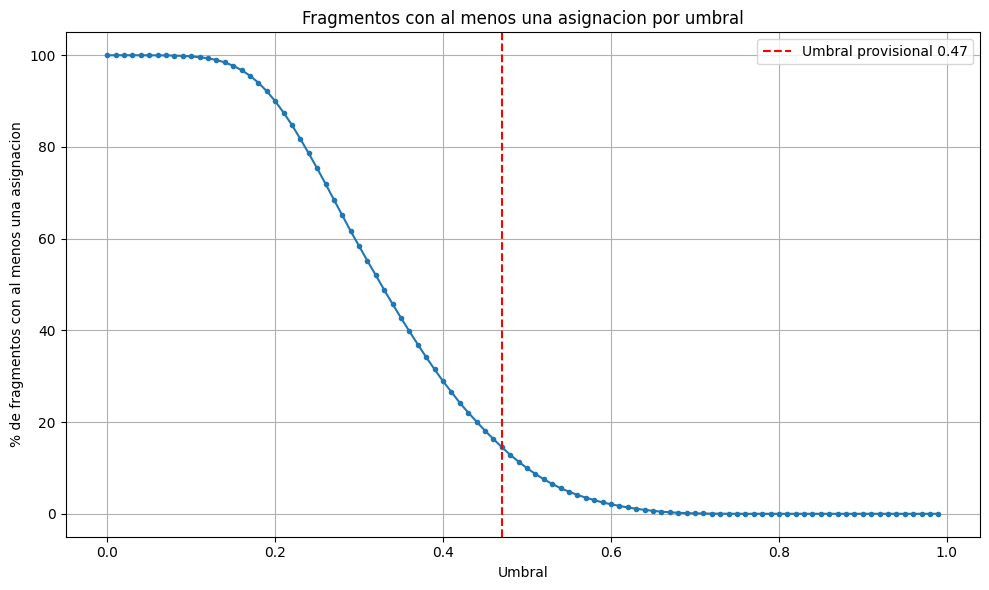

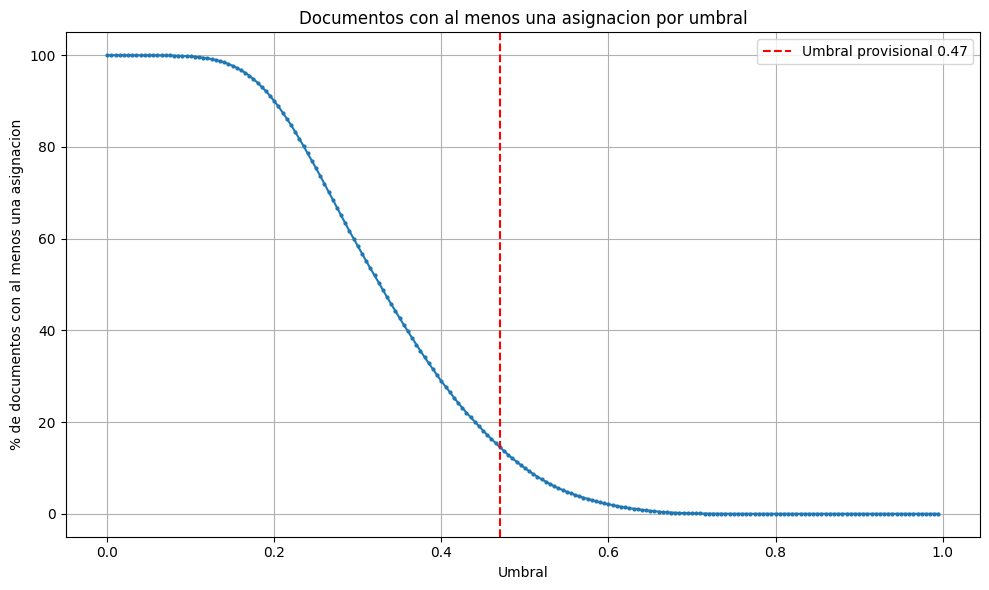

Descriptivos por subcategoria:
                                  count    mean     std     min     25%     50%     75%     max
Salud_Control_alimentos        151424.0  0.1291  0.0830 -0.2084  0.0723  0.1211  0.1767  0.6851
Salud_Economia_salud           151424.0  0.1709  0.0951 -0.1303  0.1032  0.1616  0.2290  0.7095
Salud_Epidemiologia            151424.0  0.2765  0.1330 -0.1118  0.1768  0.2534  0.3604  0.7858
Salud_Estadisticas_sanitarias  151424.0  0.2353  0.1094 -0.1256  0.1510  0.2310  0.3144  0.7073
Salud_Higiene                  151424.0  0.2013  0.1015 -0.1932  0.1318  0.1916  0.2612  0.7827
Salud_Higiene_ambiental        151424.0  0.1618  0.0858 -0.1301  0.1036  0.1530  0.2101  0.7196
Salud_Lucha_enfermedades       151424.0  0.2395  0.1095 -0.0683  0.1551  0.2275  0.3146  0.6479
Salud_Materno_infantil         151424.0  0.2042  0.0871 -0.1273  0.1419  0.2015  0.2625  0.6976
Salud_Mental                   151424.0  0.0923  0.0701 -0.1676  0.0456  0.0895  0.1354  0.6420
Salud_Pol

In [10]:
# ============================================================
# CELL 9 — ESTADISTICOS Y CURVA DEL UMBRAL
# Equivalente a celdas 28-31 del paper
# ============================================================

subcats        = list(subcat_embeddings.keys())
# columnas de subcategorias en sim_df (excluyendo chunk_id, id_doc, texto_chunk)
subcat_cols_df = [c for c in sim_df.columns if c not in ['chunk_id', 'id_doc', 'texto_chunk']]

sim_temp = sim_df[subcat_cols_df].astype(float)

# --- Asignaciones por subcategoria con umbral provisional (Karen cell 28) ---
asign_por_subcat = (sim_temp >= UMBRAL_PROVISIONAL).sum().sort_values(ascending=False)
print('Asignaciones por subcategoria:')
print(asign_por_subcat.to_string())
print()

# --- Curva: % chunks con al menos una asignacion por umbral (Karen cell 29) ---
import numpy as np
umbrales = np.arange(0, 1, 0.01)
chunks_con_asignacion = [
    (sim_temp >= u).any(axis=1).sum() / len(sim_temp) * 100
    for u in umbrales
]

plt.figure(figsize=(10, 6))
plt.plot(umbrales, chunks_con_asignacion, marker='o', markersize=3)
plt.axvline(UMBRAL_PROVISIONAL, color='red', linestyle='--',
            label=f'Umbral provisional {UMBRAL_PROVISIONAL}')
plt.xlabel('Umbral')
plt.ylabel('% de fragmentos con al menos una asignacion')
plt.title('Fragmentos con al menos una asignacion por umbral')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_curva_umbral_chunks.png', dpi=150)
plt.show()

# --- Curva: % docs con al menos una asignacion (Karen cell 30) ---
subcat_cols_doc = [c for c in sim_docs_df_merged.columns
                   if c not in ['id_doc', 'texto_chunk']]
sim_temp_doc = sim_docs_df_merged[subcat_cols_doc].astype(float)

umbrales2 = np.arange(0, 1, 0.005)
docs_con_asignacion = [
    (sim_temp_doc >= u).any(axis=1).sum() / len(sim_temp_doc) * 100
    for u in umbrales2
]

plt.figure(figsize=(10, 6))
plt.plot(umbrales2, docs_con_asignacion, marker='o', markersize=2)
plt.axvline(UMBRAL_PROVISIONAL, color='red', linestyle='--',
            label=f'Umbral provisional {UMBRAL_PROVISIONAL}')
plt.xlabel('Umbral')
plt.ylabel('% de documentos con al menos una asignacion')
plt.title('Documentos con al menos una asignacion por umbral')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_curva_umbral_docs.png', dpi=150)
plt.show()

# --- Descriptivos por subcategoria (Karen cell 32-33) ---
descriptivos = sim_temp.describe().T.round(4)
print('Descriptivos por subcategoria:')
print(descriptivos.to_string())

## 10 · Asignación con umbral provisional
Replica exacta de `uss.asignar_categorias()`:  
itera fila por fila, añade todas las subcategorías que superan el umbral  
como lista de tuplas `(subcategoria, score)` en el orden de las columnas.  
Si ninguna supera: `[('ninguna', 0)]`.

In [11]:
# ============================================================
# CELL 10 — ASIGNACION CON UMBRAL
# Replica exacta de uss.asignar_categorias(df, umbral)
# ============================================================

def asignar_categorias(df, umbral=0.30):
    """
    Replica exacta de uss.asignar_categorias().
    Itera fila por fila. Excluye columnas chunk_id, id_doc, texto_chunk.
    Retorna lista de tuplas (subcategoria, score) — sin ordenar por score.
    Si ninguna supera: [('ninguna', 0)]
    """
    categorias_detectadas = []
    for _, fila in df.iterrows():
        cats = []
        for col in df.columns:
            if col not in ['chunk_id', 'id_doc', 'texto_chunk']:
                if fila[col] >= umbral:
                    cats.append((col, fila[col]))
        categorias_detectadas.append(cats if cats else [('ninguna', 0)])

    df = df.copy()
    df['categorias_detectadas'] = categorias_detectadas
    return df


print(f'Asignando categorias con umbral provisional {UMBRAL_PROVISIONAL}...')
print('(iteracion fila a fila — puede tardar unos minutos con 151K tweets)')
resultado = asignar_categorias(sim_df, umbral=UMBRAL_PROVISIONAL)

# Etiqueta binaria — identica a Karen:
# resultado['etiqueta_ciencia'] = resultado['categorias_detectadas'].apply(
#     lambda x: 1 if x[0][0] != 'ninguna' else 0)
resultado['etiqueta_salud'] = resultado['categorias_detectadas'].apply(
    lambda x: 1 if x[0][0] != 'ninguna' else 0
)

resultado.head(3)

Asignando categorias con umbral provisional 0.47...
(iteracion fila a fila — puede tardar unos minutos con 151K tweets)


,chunk_id,id_doc,texto_chunk,Salud_Control_alimentos,Salud_Economia_salud,Salud_Epidemiologia,Salud_Estadisticas_sanitarias,Salud_Higiene,Salud_Higiene_ambiental,Salud_Lucha_enfermedades,Salud_Materno_infantil,Salud_Mental,Salud_Politica_drogas,Salud_Salud_mujer,Salud_Toxicomania,categorias_detectadas,etiqueta_salud
0,1_1,1,VDEO Reos que no están contagiados con COVID19...,0.140581,0.114366,0.408011,0.208025,0.217807,0.157840,0.290441,0.222994,-0.008854,0.075682,0.206750,0.089728,"[(ninguna, 0)]",0
1,2_1,2,ya se enteraron de la muerte supestamente por ...,0.069153,0.166314,0.231262,0.302686,0.169094,0.105943,0.257280,0.281144,0.167494,0.163025,0.338464,0.166073,"[(ninguna, 0)]",0
2,3_1,3,El calvario de una familia en Cali por su mamá...,0.105749,0.218547,0.161699,0.265029,0.189123,0.115415,0.188642,0.336182,0.286943,0.163512,0.440129,0.200752,"[(ninguna, 0)]",0


## 11 · Estadísticos del resultado

In [12]:
# ============================================================
# CELL 11 — ESTADISTICOS DEL RESULTADO
# Equivalente a celdas 26-27 del paper
# ============================================================

# Distribucion de categorias_detectadas (Karen cell 26)
print('Top combinaciones de categorias_detectadas:')
print(resultado['categorias_detectadas'].apply(str).value_counts().head(15).to_string())
print()

# Docs con al menos una categoria (Karen cell 27)
docs_con_categoria = resultado[
    resultado['categorias_detectadas'].apply(lambda x: x[0][0] != 'ninguna')
]['id_doc'].nunique()
print(f'Tweets con al menos una categoria de salud : {docs_con_categoria:,}')
pct = docs_con_categoria / len(resultado) * 100
print(f'Porcentaje                                 : {pct:.1f}%')

Top combinaciones de categorias_detectadas:
categorias_detectadas
[('ninguna', 0)]                                       129408
[('Salud_Epidemiologia', 0.5763486623764038)]               5
[('Salud_Epidemiologia', 0.5225095748901367)]               3
[('Salud_Epidemiologia', 0.4844452142715454)]               2
[('Salud_Epidemiologia', 0.5117084980010986)]               2
[('Salud_Epidemiologia', 0.4760541021823883)]               2
[('Salud_Epidemiologia', 0.5833348631858826)]               2
[('Salud_Epidemiologia', 0.5261562466621399)]               2
[('Salud_Epidemiologia', 0.5147817134857178)]               2
[('Salud_Lucha_enfermedades', 0.47465550899505615)]         2
[('Salud_Epidemiologia', 0.5999535918235779)]               2
[('Salud_Higiene', 0.5279214382171631)]                     2
[('Salud_Epidemiologia', 0.6386483311653137)]               2
[('Salud_Salud_mujer', 0.6181908249855042)]                 2
[('Salud_Higiene', 0.5247056484222412)]                     2

Twe

## 12 · Guardar resultados finales

In [13]:
# ============================================================
# CELL 12 — GUARDAR RESULTADOS FINALES
# Equivalente a:
#   resultado.to_excel('chunks_etiquetados_binario.xlsx')
#   resultado_ciencia.to_excel('ciencia_chunks.xlsx')
# ============================================================

# Serializar categorias_detectadas a string para parquet
resultado_save = resultado.copy()
resultado_save['categorias_detectadas'] = resultado_save['categorias_detectadas'].apply(str)

# Todos los tweets etiquetados (binario)
resultado_save.to_parquet(DATA_PROCESSED / 'tweets_etiquetados_binario.parquet', index=False)
resultado_save.to_excel(DATA_PROCESSED / 'chunks_etiquetados_binario.xlsx', index=False, engine='openpyxl')
print(f'[GUARDADO] tweets_etiquetados_binario  ({len(resultado_save):,} filas)')

# Solo tweets de salud (equivalente a resultado_ciencia del paper)
resultado_salud = resultado[
    resultado['categorias_detectadas'].apply(lambda x: x[0][0] != 'ninguna')
].copy()
resultado_salud_save = resultado_salud.copy()
resultado_salud_save['categorias_detectadas'] = resultado_salud_save['categorias_detectadas'].apply(str)

resultado_salud_save.to_parquet(DATA_PROCESSED / 'salud_tweets.parquet', index=False)
resultado_salud_save.to_excel(DATA_PROCESSED / 'salud_chunks.xlsx', index=False, engine='openpyxl')
print(f'[GUARDADO] salud_tweets                ({len(resultado_salud_save):,} filas)')

print()
print(f'  Total tweets         : {len(resultado):,}')
print(f'  Tweets con salud     : {len(resultado_salud):,} ({len(resultado_salud)/len(resultado)*100:.1f}%)')
print(f'  Umbral usado (prov.) : {UMBRAL_PROVISIONAL}')
print()
print('Notebook 03 completado.')
print('Siguiente -> 04_seleccion_umbral.ipynb')

[GUARDADO] tweets_etiquetados_binario  (151,424 filas)
[GUARDADO] salud_tweets                (22,016 filas)

  Total tweets         : 151,424
  Tweets con salud     : 22,016 (14.5%)
  Umbral usado (prov.) : 0.47

Notebook 03 completado.
Siguiente -> 04_seleccion_umbral.ipynb
